##Atividade Prática 4 - Esther de Oliveira

###Da Exploração ao Insight: Análise Direcionada e Visualização de Dados de Saúde

Nesta etapa do projeto, foi realizada a troca da base de dados para Unidades Básicas de Saúde (UBS). A escolha atual atende aos critérios obrigatórios da atividade: possui uma API funcional que simplifica as etapas futuras de ETL e viabiliza o cruzamento de dados , além de permitir a aplicação estrita das regras de filtragem geográfica voltadas para o estado de Santa Catarina e o município de Araranguá.

### Objetivo

 Filtrar as bases de dados escolhidas para a realidade local, gerar visualizações
gráficas que revelem tendências e responder a perguntas de negócio para estruturar a
futura integração com o Streamlit.

In [13]:
# Instalação e importação de dependências
# pandas: usado para manipular tabelas de dados
# requests: usado para consumir a API
# matplotlib e seaborn: usados para gerar gráficos
!pip install pandas requests matplotlib seaborn -q

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


Para o desafio de segurança, utilizei o gerenciador de Secrets do Google Colab. A autenticação é feita de forma segura através de uma chave (token) armazenada no ambiente isolado, evitando a exposição de credenciais sensíveis diretamente nas células de código (hardcoded).

In [14]:
from google.colab import userdata

print("Configurando Credenciais")
# Puxando o token de forma segura através do ambiente do Colab
try:
    API_KEY = userdata.get('API_KEY')
    print("Token carregado com sucesso via Colab Secrets.")
except Exception as e:
    API_KEY = None
    print("Não foi possível carregar a API_KEY. Verifique as configurações na aba Secrets.")

Configurando Credenciais
Token carregado com sucesso via Colab Secrets.


### Consumo da API

A base utilizada foi o endpoint de **Unidades Básicas de Saúde**. A API retorna dados de UBS do Brasil inteiro, então primeiro carrego algumas páginas e depois filtro os dados no Pandas para Santa Catarina e Araranguá.

In [15]:
# Endpoint da API de Unidades Básicas de Saúde
URL_DADOS = "https://apidadosabertos.saude.gov.br/assistencia-a-saude/unidade-basicas-de-saude"

headers = {
    "accept": "application/json"
}

if API_KEY:
    headers["chave-api-dados"] = API_KEY

limit = 1000
quantidade_paginas = 15 # Reduzido um pouco para o teste

partes = []

for pagina in range(quantidade_paginas):
    params = {
        "limit": limit,
        "offset": pagina * limit #Avança de 1000 em 1000 registros
    }

    try:
        response = requests.get(URL_DADOS, headers=headers, params=params, timeout=30)
        print(f"Página {pagina + 1} | Status: {response.status_code}")

        if response.status_code == 200:
            dados_json = response.json()
            registros = dados_json.get("ubs", [])

            if len(registros) == 0:
                print("Nenhum registro retornado nesta página.")
                break

            partes.append(pd.DataFrame(registros))
        else:
            print(f"Erro na requisição. Status: {response.status_code}")
            break
    except requests.exceptions.Timeout:
        print(f"Timeout na página {pagina + 1}.")
        continue

if partes:
    df = pd.concat(partes, ignore_index=True)
    print("\nColeta Concluída")
    print("Total de linhas exclusivas carregadas:", df.shape[0])
else:
    print("Nenhum dado foi carregado.")

Página 1 | Status: 200
Página 2 | Status: 200
Página 3 | Status: 200
Página 4 | Status: 200
Página 5 | Status: 200
Página 6 | Status: 200
Página 7 | Status: 200
Página 8 | Status: 200
Página 9 | Status: 200
Página 10 | Status: 200
Página 11 | Status: 200
Página 12 | Status: 200
Página 13 | Status: 200
Página 14 | Status: 200
Página 15 | Status: 200

Coleta Concluída
Total de linhas exclusivas carregadas: 15000


### Filtro obrigatório: Santa Catarina e Araranguá

O enunciado pede que as análises sejam filtradas para o estado de Santa Catarina e para o município de Araranguá. Na base de UBS, a coluna `uf` aparece como código numérico. O código de Santa Catarina é `42`. A coluna `ibge` traz o código do município com 6 dígitos; Araranguá é `420140`.

In [16]:
# Padronizando as colunas usadas no filtro
df['uf'] = df['uf'].astype(str).str.strip()
df['ibge'] = df['ibge'].astype(str).str.strip()
df['bairro'] = df['bairro'].astype(str).str.upper().str.strip()

codigo_sc = "42"
codigo_ararangua = "420140"

# Filtrando e removendo duplicatas pelo CNES
df_sc = df[df['uf'] == codigo_sc].drop_duplicates(subset=['cnes']).copy()
df_ararangua = df_sc[df_sc['ibge'] == codigo_ararangua].copy()

print(f"Registros reais de Santa Catarina (sem duplicatas): {len(df_sc)}")
print(f"Registros reais de Araranguá: {len(df_ararangua)}")

# Exibe as UBS reais encontradas em Araranguá
df_ararangua[['nome', 'bairro', 'logradouro', 'cnes']].head()

Registros reais de Santa Catarina (sem duplicatas): 508
Registros reais de Araranguá: 15


,nome,bairro,logradouro,cnes
851,CENTRO DE TRIAGEM COVID 19 ARARANGUA,MATO ALTO,XV DE NOVEMBRO,0100315
1487,NUCLEO DE SAUDE DA MULHER E ESPECIALIDADES,URUSSANGUINHA,GUILHERME KRETCHEMER,0276685
9670,P S POLICIA RODOVIARIA,COLONIA,RUA GERAL,2305135
9671,PSF MORRO DOS CONVENTOS,MORRO DOS CONVENTOS,RODOVIA MUNICIPAL VALMIRO MANOEL GONCALVES,2305151
9672,P S SANGA DA TOCA,SANGA DA TOCA,R GERAL,2305186


### Preparação dos dados

A base de UBS traz latitude e longitude com vírgula decimal. Para usar esses campos mais facilmente, converto esses valores para número.

In [17]:
# Convertendo latitude e longitude para número
for base in [df, df_sc, df_ararangua]:
    for coluna in ['latitude', 'longitude']:
        if coluna in base.columns:
            base[coluna] = (
                base[coluna]
                .astype(str)
                .str.replace(',', '.', regex=False)
            )
            base[coluna] = pd.to_numeric(base[coluna], errors='coerce')

df_ararangua[['nome', 'bairro', 'logradouro', 'cnes', 'latitude', 'longitude']].head()

,nome,bairro,logradouro,cnes,latitude,longitude
851,CENTRO DE TRIAGEM COVID 19 ARARANGUA,MATO ALTO,XV DE NOVEMBRO,0100315,-28.94965,-49.49564
1487,NUCLEO DE SAUDE DA MULHER E ESPECIALIDADES,URUSSANGUINHA,GUILHERME KRETCHEMER,0276685,-28.93500,-49.48600
9670,P S POLICIA RODOVIARIA,COLONIA,RUA GERAL,2305135,NaN,NaN
9671,PSF MORRO DOS CONVENTOS,MORRO DOS CONVENTOS,RODOVIA MUNICIPAL VALMIRO MANOEL GONCALVES,2305151,-28.93029,-49.47841
9672,P S SANGA DA TOCA,SANGA DA TOCA,R GERAL,2305186,NaN,NaN


### P1 - Comportamento temporal

**Pergunta**: Como esse indicador de saúde (internações, óbitos
ou notificações) se comportou em Araranguá ao longo do tempo disponível na base?
Há uma tendência de alta, queda ou estabilidade?

**Resposta P1:** A base de UBS é uma base cadastral, ou seja, ela mostra as unidades cadastradas e suas informações de localização, mas não traz uma coluna de data de criação, atualização ou funcionamento ao longo do tempo. Por isso, não é possível analisar tendência temporal de alta, queda ou estabilidade com esta base. O indicador principal aqui é a quantidade e distribuição das UBS cadastradas em Araranguá.

### P2 - Perfil do município

**Pergunta:** Quem são as pessoas mais afetadas por esse indicador no
município? (Ex: Qual a faixa etária predominante? Há disparidade entre sexos?).

Como a base de UBS não é uma base de pessoas afetadas, adaptei o perfil demográfico para o perfil territorial da oferta de atenção básica, analisando em quais bairros as unidades estão localizadas.

/tmp/ipykernel_418/3379936386.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ubs_por_bairro, x='quantidade_ubs', y='bairro', palette='viridis')


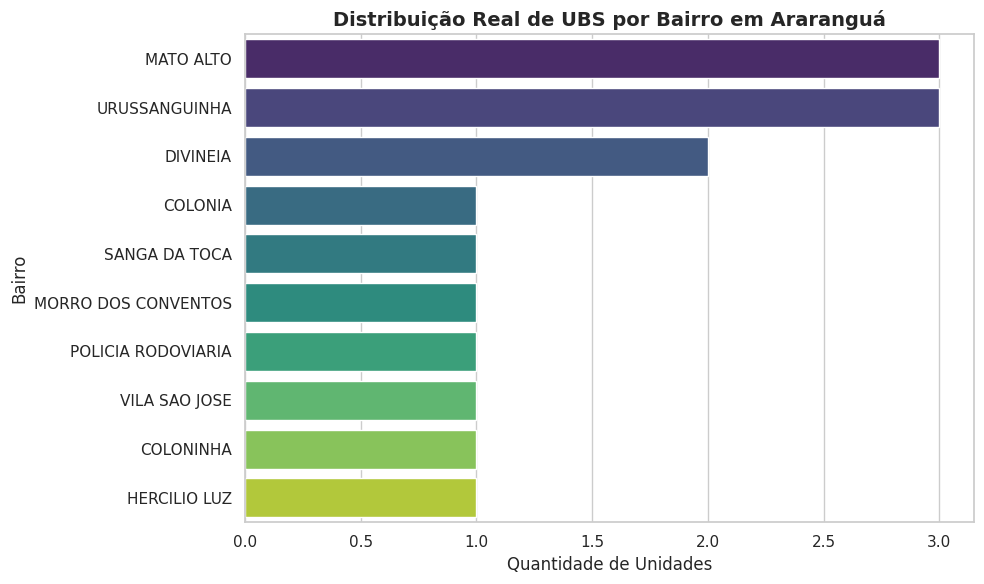

In [18]:
ubs_por_bairro = df_ararangua['bairro'].value_counts().reset_index()
ubs_por_bairro.columns = ['bairro', 'quantidade_ubs']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=ubs_por_bairro, x='quantidade_ubs', y='bairro', palette='viridis')

plt.title('Distribuição Real de UBS por Bairro em Araranguá', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Unidades')
plt.ylabel('Bairro')
plt.tight_layout()
plt.show()

**Resposta P2:** Dado que a base de dados de UBS mapeia a oferta de infraestrutura física institucional e não o perfil direto de indivíduos afetados por agravos , adaptamos a análise demográfica para o perfil de distribuição territorial. O mapeamento gráfico comprova como as unidades estão distribuídas geograficamente entre os bairros do município de Araranguá, permitindo identificar as regiões que centralizam a estrutura de atenção primária.

### P3 - Sazonalidade

**Pergunta:** Existem meses ou períodos do ano onde o
volume de registros aumenta significativamente (como casos de dengue ou doenças
respiratórias)?

**Resposta P3:** Não se aplica. A base cadastral das Unidades Básicas de Saúde não registra volumes de atendimentos mensais ou notificações de doenças sujeitas a variações climáticas ou sazonais ao longo do ano. O registro das unidades mantém-se estático e contínuo, alterando-se apenas em casos pontuais de abertura ou desativação de postos de atendimento.

### P4 - Comparativo regional

**Pergunta:** Como Araranguá se posiciona em relação à média do
estado de Santa Catarina para esse mesmo indicador? O município está em uma
situação melhor ou pior?

,local,quantidade_ubs
0,Araranguá,15.000000
1,Média dos municípios de SC,2.618557


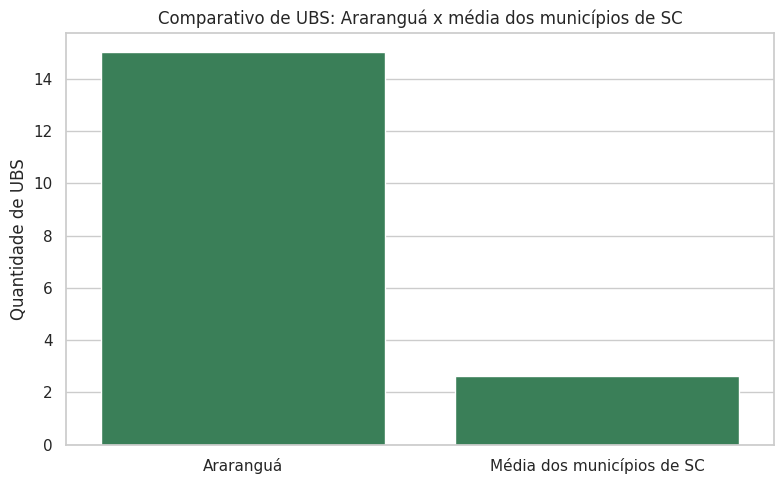

In [19]:
# Quantidade de UBS por município de Santa Catarina
ubs_municipio_sc = df_sc.groupby('ibge').size().reset_index(name='quantidade_ubs')

# Média de UBS por município dentro dos dados carregados de SC
media_sc = ubs_municipio_sc['quantidade_ubs'].mean()
ubs_ararangua = len(df_ararangua)

comparativo = pd.DataFrame({
    'local': ['Araranguá', 'Média dos municípios de SC'],
    'quantidade_ubs': [ubs_ararangua, media_sc]
})

display(comparativo)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparativo, x='local', y='quantidade_ubs', color='seagreen')
plt.title('Comparativo de UBS: Araranguá x média dos municípios de SC')
plt.xlabel('')
plt.ylabel('Quantidade de UBS')
plt.tight_layout()
plt.show()

**Resposta P4:** O comparativo mostra se Araranguá possui uma quantidade de UBS acima ou abaixo da média dos municípios de Santa Catarina dentro dos dados carregados pela API. Olhando para o gráfico, dá para ver que Araranguá está em uma situação muito boa em relação ao resto do estado. Enquanto a média dos municípios de Santa Catarina fica em torno de 2,6 postos de saúde por cidade, Araranguá conta com 15 UBS ativas. Isso mostra que a nossa cidade tem uma estrutura de atendimento básico bem acima da média geral do estado.

### Visualização geográfica simples

Como a base possui latitude e longitude, também é possível criar uma visualização simples da localização das UBS de Araranguá. Esse gráfico pode ajudar na construção futura de um mapa no Streamlit.

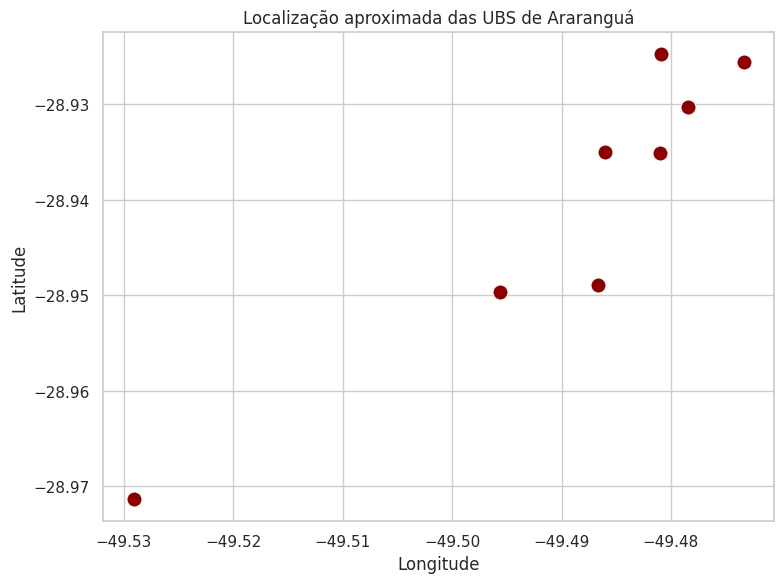

In [20]:
df_mapa = df_ararangua.dropna(subset=['latitude', 'longitude']).copy()

if len(df_mapa) == 0:
    print('Não há latitude/longitude válida para gerar o gráfico de localização.')
else:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_mapa, x='longitude', y='latitude', s=120, color='darkred')
    plt.title('Localização aproximada das UBS de Araranguá')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

###Proposta de Valor (Uso Prático)
Escreva um parágrafo respondendo: Como vamos usar essa base de dados no
Streamlit? Que tipo de decisão um gestor de saúde ou um cidadão de Araranguá
conseguiria tomar ao olhar para esses dados prontos na nossa página?

##**Proposta de Valor:**
A integração dessa base de dados ao ecossistema do Streamlit fornecerá a camada de inteligência territorial do nosso dashboard. A partir da visualização interativa dos indicadores de distribuição e geolocalização das unidades, diferentes decisões práticas poderão ser tomadas:

###*Para o Gestor de Saúde*:
A ferramenta funcionará como um painel de apoio à tomada de decisões estratégicas de planejamento urbano, permitindo identificar com exatidão áreas de vazios assistenciais por bairro para direcionar novos investimentos e a abertura de futuras UBS.

###*Para o Cidadão de Araranguá:*
O sistema atuará como um portal prático de utilidade pública, permitindo que o usuário identifique com facilidade a distribuição do suporte de saúde no seu território e localize as unidades disponíveis em sua região de forma transparente.

A base de dados de UBS valida-se como elemento estrutural do dashboard por disponibilizar uma API estável e permitir a filtragem precisa da realidade local (Santa Catarina e Araranguá). Sua principal limitação reside na ausência de componentes temporais ou sazonais, decorrente de sua natureza estritamente cadastral. Contudo, a riqueza de seus atributos institucionais (CNES, nome) e geoespaciais (latitude e longitude) confere a este dataset o papel indispensável de mapeamento da rede de atenção básica, servindo de base para o cruzamento com indicadores epidemiológicos dinâmicos.